# NLP session 1 - Word Semantics
- Prerequisite
    - Upload the MTSamples corpus
- Distributed reprentation using co-occurrence matrices
    - Term-document vs term-term
    - TF-IDF and Positive pointwise mutual information
- Compare different vector reprentations
    - Results on three types of word meanings
    - Visualisation
    - Document classification task

# 1. Prerequisite
The official MTSamples website: https://www.mtsamples.com/.
Upload the preprocessed MTSamples `mtsamples_ihi.csv` provided with the lab.

# 2. Distributed representations
- Learn the meaning of a word by its **distribution** in language use, i.e.,
its neighbouring words or grammatical environments

## 2.1 Term-document matrix
- Preprocessing: use SpaCy lemmanisation, remove stop words and non-letter tokens

In [2]:
import random
import pandas as pd

# read mtsamples
df_mtsamples = pd.read_csv('mtsamples_ihi.csv')
df_mtsamples.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,SUBJECTIVE:\n\n This 23-year-old white female...,"allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,PAST MEDICAL HISTORY:\n\n He has difficulty cl...,"bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,HISTORY OF PRESENT ILLNESS: \n\n I have seen A...,"bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,2-D M-MODE: \n\n \n\n1. Left atrial enlargeme...,"cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [3]:
df_mtsamples['medical_specialty'].value_counts()

,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


In [4]:
# get some random files
def sampling_by_category(category, df, n_files):
    seed = 6
    cat_files = df[df['medical_specialty'].str.strip() == category]
    sampled = cat_files.sample(n=min(cat_files.shape[0], n_files), random_state=seed)

    print('pick %s rows of %s (total=%s)' % (n_files, category, cat_files.shape[0]))
    return sampled.index.to_list()


n_docs_per_cat = 20
indices = []
categories = ['Surgery', 'Cardiovascular / Pulmonary', 'Radiology']
for cat in categories:
    indices += sampling_by_category(cat, df_mtsamples, n_docs_per_cat)

df_sampled = df_mtsamples.loc[indices]
df_sampled.head()

pick 20 rows of Surgery (total=1103)
pick 20 rows of Cardiovascular / Pulmonary (total=372)
pick 20 rows of Radiology (total=273)


,description,medical_specialty,sample_name,transcription,keywords
1099,Left heart catheterization with coronary angi...,Surgery,Cardiac Catheterization - 5,PROCEDURE PERFORMED:\n\n1. Left heart catheter...,"surgery, catheterization, vein graft, angiogra..."
695,Left communicating hydrocele. Left inguinal ...,Surgery,Inguinal Hernia & Hydrocele Repair,PREOPERATIVE DIAGNOSIS: \n\nLeft communicatin...,"surgery, hydrocele, hydrocele repair, hernia, ..."
484,Open reduction and internal fixation of the l...,Surgery,ORIF & Closed Reduction,PREOPERATIVE DIAGNOSES: \n\n Left elbow fractu...,"surgery, orif, elbow fracture, dislocation, op..."
1245,Anterior cervical discectomy fusion C3-C4 and...,Surgery,Anterior Cervical Discectomy & Fusion,PREOPERATIVE DIAGNOSES:\n\n Cervical spondylo...,"surgery, titanium plates fixation, bone black ..."
989,Patient with history of adenomas and irregula...,Surgery,Colonoscopy - 7,PROCEDURE:\n\n Colonoscopy.\n\nPREOPERATIVE D...,"surgery, colon polyps, internal hemorrhoids, r..."


In [5]:
df_sampled['medical_specialty'].value_counts()

,count
medical_specialty,
Surgery,20
Cardiovascular / Pulmonary,20
Radiology,20


#  Task 1. Generate term-document matrix from `df_sampled`
- Return a pandas dataframe: columns are documents and rows are terms
- Use SpaCy lemmatization

In [6]:
import spacy
nlp = spacy.load('en_core_web_sm')

# a dictionary of dictionary to hold document-term freqencies
term_doc = {}
# a dictionary to hold overall term frequencies
term_freq = {}

for idx, text in zip(indices, df_sampled['transcription']):
    doc = nlp(text)
    term_doc[idx] = {}
    for t in doc:
        # ignore stop words, punctuations and non-letter tokens
        if not (t.is_stop or t.is_punct) and t.is_alpha:
            # get the lemma form
            tl = t.lemma_.lower()
            term_freq[tl] =  1 if tl not in term_freq else 1 + term_freq[tl]
            term_doc[idx][tl] =  1 if tl not in term_doc[idx] else 1 + term_doc[idx][tl]
print('vocabulary size', len(term_freq))

# sort the terms by their frequency in descending order
sorted_terms = [term for term, freq in sorted(term_freq.items(), key=lambda item: item[1], reverse=True)]

# create a dataframe for storing the term-document matrix
df = pd.DataFrame()
for d in term_doc:
    col = []
    for t in sorted_terms:
        col.append(term_doc[d][t] if t in term_doc[d] else 0)
    df[d] = col
df.index = sorted_terms
df.describe()

vocabulary size 3167


,1099,695,484,1245,989,806,1239,1155,266,1003,...,1658,1679,1624,1505,1617,1748,1599,1731,1697,1580
count,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,...,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000
mean,0.145564,0.076413,0.115567,0.073571,0.037575,0.099147,0.178718,0.071992,0.059046,0.033154,...,0.082412,0.087149,0.113356,0.139880,0.040101,0.080518,0.074518,0.028102,0.033786,0.072940
std,0.794782,0.424126,0.582353,0.376949,0.274483,0.512284,0.795368,0.493670,0.353646,0.218765,...,0.520426,0.426516,0.509637,0.628607,0.294135,0.374684,0.436206,0.245296,0.231303,0.470934
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,16.000000,10.000000,10.000000,5.000000,5.000000,10.000000,21.000000,10.000000,6.000000,4.000000,...,9.000000,5.000000,12.000000,11.000000,5.000000,5.000000,8.000000,6.000000,4.000000,9.000000


In [7]:
df.head(10)

,1099,695,484,1245,989,806,1239,1155,266,1003,...,1658,1679,1624,1505,1617,1748,1599,1731,1697,1580
patient,6,7,10,1,3,7,6,3,2,1,...,3,2,4,11,2,3,0,4,0,0
left,8,4,4,0,1,9,3,1,1,0,...,0,0,7,5,0,2,4,0,0,0
right,13,0,5,0,0,0,1,2,0,0,...,1,5,0,3,1,4,3,0,3,2
artery,16,0,0,0,0,0,0,0,0,0,...,1,0,4,1,0,0,3,0,0,0
normal,3,0,1,0,3,0,0,3,0,4,...,8,2,0,7,0,0,8,0,1,8
procedure,5,1,3,4,2,4,4,4,0,1,...,2,0,0,5,2,0,0,0,0,0
leave,7,3,2,0,0,2,0,1,1,1,...,0,0,0,5,1,1,2,0,1,0
coronary,14,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
place,0,1,5,5,1,5,6,2,0,0,...,0,0,2,2,3,2,0,0,0,0
anterior,1,0,1,2,0,0,10,0,0,0,...,1,0,0,0,0,2,0,0,1,3


In [8]:
terms = pd.DataFrame([sum(df.loc[r]) for r in df.index])
terms.index = df.index
terms.columns = ['freq']
terms.sort_values(by='freq', ascending=False, inplace=True)
terms.head(20)

,freq
patient,251
left,174
right,172
artery,169
normal,148
procedure,100
leave,90
coronary,85
place,81
anterior,74


# Task 2 Generate term-term matrix

In [9]:
def process_token(token, context, t2c):
    # check if the token is not already in the term-to-context dictionary
    if token not in t2c:
        t2c[token] = {}
    # iterate through each context term and update its frequency in the dictionary
    for c in context:
        t2c[token][c] = t2c[token].get(c, 0) + 1

def build_term_context_matrix(text_array, win_size=4):
    nlp = spacy.load('en_core_web_sm')
    t2c = {}

    # iterate through each text in the text array
    for text in text_array:
        doc = nlp(text)
        # extract lemmatised tokens that are not stop words, punctuation, and are alphabetic
        tokens = [t.lemma_.lower() for t in doc if not (t.is_stop or t.is_punct) and t.is_alpha]

        # iterate through each token and its index in the tokens list
        for i, token in enumerate(tokens):
            # define the context window around the token
            context = tokens[max(0, i - win_size):i] + tokens[i + 1:i + 1 + win_size]
            # process the token with its context to update the term-to-context dictionary
            process_token(token, context, t2c)

    print('vocabulary size:', len(t2c))
    return t2c

t2c = build_term_context_matrix(df_sampled['transcription'].tolist())

vocabulary size: 3167


In [10]:
# create a dataframe to store the term-term matrix
terms = []
contexts = []
for t in t2c:
    if t not in terms:
        terms.append(t)
    for c in t2c[t]:
        if c not in contexts:
            contexts.append(c)
data = {}
for t in terms:
    data[t] = [(t2c[t][c] if c in t2c[t] else 0) for c in contexts]

tt_df = pd.DataFrame.from_dict(data, orient='index', dtype=int)
tt_df.columns = contexts
tt_df.describe()

,performed,left,heart,catheterization,arteriotomy,angio,seal,indication,patient,know,...,chf,glucose,rbc,sitting,resp,urgency,tia,involvement,acetazolamide,kinase
count,3167.000000,3167.000000,3167.000000,3167.00000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,...,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000
mean,0.028418,0.436691,0.123776,0.05431,0.007578,0.017682,0.017682,0.038522,0.627723,0.022734,...,0.002526,0.007578,0.002526,0.002526,0.002526,0.002526,0.002526,0.002526,0.002526,0.002526
std,0.236741,1.975454,0.633224,0.49529,0.127934,0.215485,0.228297,0.314576,1.829091,0.183291,...,0.050204,0.114928,0.056144,0.050204,0.050204,0.050204,0.050204,0.050204,0.050204,0.056144
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,7.000000,61.000000,19.000000,14.00000,4.000000,7.000000,7.000000,8.000000,43.000000,4.000000,...,1.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [11]:
tt_df.loc[tt_df.index.sort_values(), tt_df.columns.sort_values()]

,abc,abcd,abdomen,abdominal,aberrant,ablation,able,abnormal,abnormality,abscess,...,xy,xylocaine,y,year,yesterday,young,z,zeta,zocor,zyvox
abc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
abcd,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abdomen,0,0,2,1,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
abdominal,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aberrant,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
young,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
z,0,0,0,0,0,0,0,0,0,0,...,2,0,0,1,0,0,0,0,0,0
zeta,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zocor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
len(contexts)

3167

# Task 3 Term weighing methods
- TF-IDF
- Positive Pointwise Mutual Information
## Task 3.1 TF-IDF on term-document matrix

In [13]:
import math

# make a deep copy of term-document matrix
tfidf_df = df.copy(deep=True)
# create a IDF dataframe
# 1.1 init it with count document frequencies
idf_df = pd.DataFrame([sum([(1 if tfidf_df.loc[t, c] > 0 else 0) for c in tfidf_df.columns]) for t in tfidf_df.index])
idf_df.index = df.index
# 1.2 calculate log10(N/df)
idf_df = idf_df.map(lambda x: math.log(tfidf_df.shape[1] / x, 10))

# 2.1 calculate log10(tf + 1)
tfidf_df = tfidf_df.map(lambda x: math.log(x + 1, 10))
# 2.2 calculate tf-idf: log10(tf + 1) * log10(N/df)
tfidf_df = tfidf_df.apply(lambda x: x * idf_df.loc[x.name, 0], axis=1)
tfidf_df.head(10)

,1099,695,484,1245,989,806,1239,1155,266,1003,...,1658,1679,1624,1505,1617,1748,1599,1731,1697,1580
patient,0.081898,0.087518,0.100921,0.029173,0.058346,0.087518,0.081898,0.058346,0.046238,0.029173,...,0.058346,0.046238,0.067737,0.104583,0.046238,0.058346,0.000000,0.067737,0.000000,0.000000
left,0.200343,0.146748,0.146748,0.000000,0.063201,0.209950,0.126402,0.063201,0.063201,0.000000,...,0.000000,0.000000,0.189603,0.163372,0.000000,0.100171,0.146748,0.000000,0.000000,0.000000
right,0.254267,0.000000,0.172632,0.000000,0.000000,0.000000,0.066783,0.105849,0.000000,0.000000,...,0.066783,0.172632,0.000000,0.133566,0.066783,0.155066,0.133566,0.000000,0.133566,0.105849
artery,0.512388,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.125356,0.000000,0.291067,0.125356,0.000000,0.000000,0.250712,0.000000,0.000000,0.000000
normal,0.133566,0.000000,0.066783,0.000000,0.133566,0.000000,0.000000,0.133566,0.000000,0.155066,...,0.211698,0.105849,0.000000,0.200349,0.000000,0.000000,0.211698,0.000000,0.066783,0.211698
procedure,0.182152,0.070466,0.140932,0.163617,0.111686,0.163617,0.163617,0.163617,0.000000,0.070466,...,0.111686,0.000000,0.000000,0.182152,0.111686,0.000000,0.000000,0.000000,0.000000,0.000000
leave,0.246545,0.164363,0.130255,0.000000,0.000000,0.130255,0.000000,0.082182,0.082182,0.082182,...,0.000000,0.000000,0.000000,0.212436,0.082182,0.082182,0.130255,0.000000,0.082182,0.000000
coronary,0.675113,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.172801,0.000000,0.172801,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
place,0.000000,0.109327,0.282607,0.282607,0.109327,0.282607,0.306921,0.173280,0.000000,0.000000,...,0.000000,0.000000,0.173280,0.173280,0.218655,0.173280,0.000000,0.000000,0.000000,0.000000
anterior,0.125356,0.000000,0.125356,0.198684,0.000000,0.000000,0.433660,0.000000,0.000000,0.000000,...,0.125356,0.000000,0.000000,0.000000,0.000000,0.198684,0.000000,0.000000,0.125356,0.250712


## Task 3.2 Positive Pointwise Mutual Information matrix

In [14]:
ppmi_df = tt_df.copy(deep=True)

# save the term frequencies first
term_probs = pd.DataFrame([sum(ppmi_df.loc[r]) for r in ppmi_df.index])
term_probs.index = tt_df.index

# save the context word frequencies first
context_probs = pd.DataFrame([sum(ppmi_df[c]) for c in ppmi_df.columns])
context_probs.index = tt_df.columns

# calculate the total word frequency
total_freq_sum = term_probs.sum()
total_freq_sum = total_freq_sum.loc[0]
print('total word occurrence times:', total_freq_sum)

total word occurrence times: 123736


In [15]:
# convert each cell from frequency to probability
ppmi_df = ppmi_df.apply(lambda x: x/total_freq_sum)
ppmi_df.head()

,performed,left,heart,catheterization,arteriotomy,angio,seal,indication,patient,know,...,chf,glucose,rbc,sitting,resp,urgency,tia,involvement,acetazolamide,kinase
procedure,0.000057,0.000048,0.000040,0.000073,0.000008,0.000024,0.000016,0.000032,0.000348,0.000008,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
performed,0.000000,0.000024,0.000032,0.000016,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
left,0.000024,0.000275,0.000065,0.000040,0.000000,0.000000,0.000000,0.000016,0.000073,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heart,0.000032,0.000065,0.000016,0.000057,0.000000,0.000000,0.000000,0.000000,0.000024,0.000008,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
catheterization,0.000016,0.000040,0.000057,0.000016,0.000000,0.000000,0.000000,0.000000,0.000073,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# get the probabilities of both context and term series
context_probs = context_probs.apply(lambda x: x/total_freq_sum)
term_probs = term_probs.apply(lambda x: x/total_freq_sum)

In [17]:
# calculate the PPMI
# 1. divide each cell by relevant term probability
ppmi_df = ppmi_df.apply(lambda r: r / term_probs.loc[r.name, 0], axis=1)
# 2. divide each cell by relevant context probability
ppmi_df = ppmi_df.apply(lambda c: c / context_probs.loc[c.name, 0])
# 3. for those non-zero cells do the log calculation and change negatives to zero
ppmi_df[ppmi_df != 0] = ppmi_df[ppmi_df != 0].map(lambda c: max(0, math.log(c, 2)))

In [18]:
ppmi_df.describe()

,performed,left,heart,catheterization,arteriotomy,angio,seal,indication,patient,know,...,chf,glucose,rbc,sitting,resp,urgency,tia,involvement,acetazolamide,kinase
count,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,...,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000
mean,0.093792,0.273308,0.208480,0.086820,0.031740,0.047202,0.046986,0.107660,0.426571,0.086750,...,0.023453,0.043886,0.022604,0.025712,0.025712,0.024681,0.024121,0.023188,0.025186,0.022867
std,0.696860,0.787776,0.873934,0.613482,0.475059,0.510921,0.534043,0.701702,0.913368,0.663016,...,0.475670,0.617007,0.481228,0.512716,0.512716,0.491980,0.481411,0.465000,0.502548,0.487124
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,7.425053,4.483320,6.302196,6.490641,9.331943,8.109551,9.109551,7.986168,4.637876,7.746981,...,10.916906,9.331943,10.916906,10.916906,10.916906,10.916906,10.916906,10.916906,10.916906,10.916906


In [19]:
ppmi_df.head(20)

,performed,left,heart,catheterization,arteriotomy,angio,seal,indication,patient,know,...,chf,glucose,rbc,sitting,resp,urgency,tia,involvement,acetazolamide,kinase
procedure,3.670165,0.000000,1.061882,3.098324,2.769701,3.132271,2.547308,2.423926,1.823826,1.184738,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
performed,0.000000,1.576430,3.810343,3.998788,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
left,1.576430,1.137198,0.868610,1.378984,0.000000,0.000000,0.000000,0.552583,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heart,3.810343,0.868610,0.687486,3.683286,0.000000,0.000000,0.000000,0.000000,0.000000,2.132271,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
catheterization,3.998788,1.378984,3.683286,3.064376,0.000000,0.000000,0.000000,0.000000,1.703464,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
coronary,1.022041,2.365711,1.706539,3.257554,0.000000,0.000000,0.000000,2.168119,0.000000,1.343969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
angiography,0.000000,1.235393,2.639231,3.827676,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
vein,0.000000,1.298896,0.658340,0.846785,0.000000,0.000000,0.000000,0.000000,0.000000,3.688087,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
graft,0.000000,0.000000,0.000000,1.583750,0.000000,0.000000,0.000000,0.000000,0.000000,4.425053,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
leave,1.963573,0.722281,1.648071,2.351090,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Task 4. Comparing vector representations
## Task 4.1 Get most similar words
- Write a function to get cosine similarity of two vectors
- List top 5 most similar words of the following list
```
words = ['diabetes', 'anticoagulation']
```

In [20]:
import pandas as pd
import math

def cosine_similarity(v1, v2):
    return (v1 @ v2) / (math.sqrt(v1 @ v1) *  math.sqrt(v2 @ v2))


In [21]:
test_df = pd.DataFrame([[10, 5, 6, 6], [2, 1, 8, 2]])
print (cosine_similarity(test_df[0], test_df[1]))
print (cosine_similarity(test_df[2], test_df[3]))

1.0000000000000002
0.8221921916437785


In [22]:
def get_top_similar(temp_df, word, k=5):
    results = []
    for t in temp_df.index:
        if t != word:
            results.append((t, cosine_similarity(temp_df.loc[word], temp_df.loc[t])))
    return sorted(results, key=lambda x: x[1], reverse=True)[:k]


In [23]:
def compare_representations(w):
    ms_words = pd.DataFrame({
        'term-document': [t[0] for t in get_top_similar(df, w)],
        'tfidf': [t[0] for t in get_top_similar(tfidf_df, w)],
        'term-term': [t[0] for t in get_top_similar(tt_df, w)],
        'PPMI': [t[0] for t in get_top_similar(ppmi_df, w)],
    })
    return ms_words

compare_representations('diabetes')

,term-document,tfidf,term-term,PPMI
0,emesis,emesis,mellitus,mellitus
1,q,dialysis,dialysis,hypercholesterolemia
2,dialysis,mb,renal,hypertension
3,mb,q,hypertension,hyperlipidemia
4,worsen,worsen,hypercholesterolemia,dialysis


In [24]:
compare_representations('anticoagulation')

,term-document,tfidf,term-term,PPMI
0,range,range,plavix,plavix
1,stenting,stroke,heparin,statin
2,stente,plavix,pigtail,heparin
3,plavix,insignificant,integrilin,integrilin
4,insignificant,culprit,catheter,aspirin


## 4.2 Visualise the given list of words in a two-dimension space
- Visualise the vector reprentations of the following words using `term-document`, `TF-IDF` and `PPMI` representations
```python
given_terms = ['diabetes', 'mellitus', 'hemorrhagic',
               'fibrillation', 'atrial',
               'stroke', 'anticoagulation']
```

- **TIP**: you can use `sklearn.decomposition.PCA `to reduce the representation dimensions into two
- **TIP**: you can use `matplotlib.pyplot.scatter` or `seaborn.scatterplot` to visualise the data

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

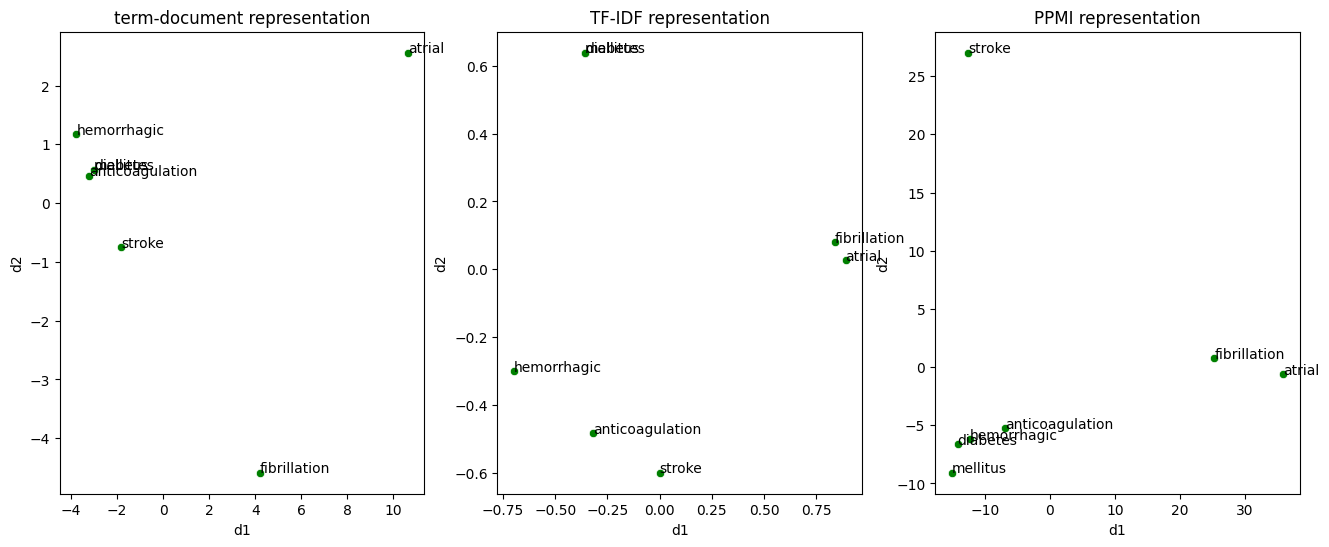

In [26]:
def vis(data, title, ax):
    pca = PCA(n_components=2)
    pca_result= pca.fit_transform(data)
    transformed = pd.DataFrame(pca_result, columns=['d1', 'd2'])
    sns.scatterplot(
        x="d1", y="d2",
        data=transformed,
        legend="full",
        color='g',
        ax=ax
    )
    for i in range(transformed.shape[0]):
        ax.text(x=transformed.d1[i],y=transformed.d2[i],s=data.index[i])
    ax.set_title(title)


given_terms = ['diabetes', 'mellitus', 'hemorrhagic',
               'fibrillation', 'atrial',
               'stroke', 'anticoagulation']

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(16,6))
vis(df.loc[given_terms], 'term-document representation', ax1)
vis(tfidf_df.loc[given_terms], 'TF-IDF representation', ax2)
vis(ppmi_df.loc[given_terms], 'PPMI representation', ax3)

## 4.3 Document classification
- Labels: use `medical_specialty` as the document class
- Features:
    - Term-Document matrix: use document vector (columns) as features
    - TF-IDF: use document vector (columns) as features
    - PPMI: use weighted (term frequency as the weight) average of all terms' context vectors (columns) as features.
    
  **TIP**: matrix multiplication can efficiently calculate the (weighted) sums

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

def do_a_vsimple_rf_classification(X, y, test_size=0.2, random_state=9):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    rfc = RandomForestClassifier(random_state=random_state)
    rfc.fit(X_train,y_train)

    # predictions
    rfc_predict = rfc.predict(X_test)
    return classification_report(y_test, rfc_predict)

# def do_a_vsimple_rf_cv(X, y, random_state=6):
#     rfc = RandomForestClassifier(random_state=random_state)
#     return cross_val_score(rfc, X, y, cv=5, scoring='f1_macro')

y = [categories.index(df_mtsamples.loc[d, 'medical_specialty'].strip()) for d in df_sampled.index]

print('========== Term frequency representation result ==========')
print(do_a_vsimple_rf_classification(df.transpose(), y))

print('==========     TF-IDF representation result     ==========')
print(do_a_vsimple_rf_classification(tfidf_df.transpose(), y))

========== Term frequency representation result ==========


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.00      0.00      0.00         6
           2       0.29      1.00      0.44         2

    accuracy                           0.50        12
   macro avg       0.36      0.67      0.44        12
weighted avg       0.31      0.50      0.37        12

==========     TF-IDF representation result     ==========
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.00      0.00      0.00         6
           2       0.29      1.00      0.44         2

    accuracy                           0.50        12
   macro avg       0.36      0.67      0.44        12
weighted avg       0.31      0.50      0.37        12



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
print('==========     PPMI representation result     ==========')
ppmi_df = ppmi_df.reindex(df.index)
print(do_a_vsimple_rf_classification(df.transpose().dot(ppmi_df), y))

==========     PPMI representation result     ==========
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.67      0.80         6
           2       0.67      1.00      0.80         2

    accuracy                           0.83        12
   macro avg       0.82      0.89      0.83        12
weighted avg       0.88      0.83      0.83        12



### Use pretrained word embeddings
- Load downloaded glove embedding `glove.6B.50d.txt` as a DataFrame instance
- Use weighted average of the embeddings as the features
- **TIP:** if using matrix multiplication, make sure the order of the first matrix's column names (i.e. terms) are in line with the second matrix's row index (again, terms). `DataFrame.reindex` can be used to reorder rows with a given index array

In [29]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-06-07 09:30:29--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-07 09:30:30--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-07 09:30:30--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [30]:
# Unzip the file: 4 different embedding sizes are provided
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [31]:
# Check the file format
!head -n10 glove.6B.50d.txt

the 0.418 0.24968 -0.41242 0.1217 0.34527 -0.044457 -0.49688 -0.17862 -0.00066023 -0.6566 0.27843 -0.14767 -0.55677 0.14658 -0.0095095 0.011658 0.10204 -0.12792 -0.8443 -0.12181 -0.016801 -0.33279 -0.1552 -0.23131 -0.19181 -1.8823 -0.76746 0.099051 -0.42125 -0.19526 4.0071 -0.18594 -0.52287 -0.31681 0.00059213 0.0074449 0.17778 -0.15897 0.012041 -0.054223 -0.29871 -0.15749 -0.34758 -0.045637 -0.44251 0.18785 0.0027849 -0.18411 -0.11514 -0.78581
, 0.013441 0.23682 -0.16899 0.40951 0.63812 0.47709 -0.42852 -0.55641 -0.364 -0.23938 0.13001 -0.063734 -0.39575 -0.48162 0.23291 0.090201 -0.13324 0.078639 -0.41634 -0.15428 0.10068 0.48891 0.31226 -0.1252 -0.037512 -1.5179 0.12612 -0.02442 -0.042961 -0.28351 3.5416 -0.11956 -0.014533 -0.1499 0.21864 -0.33412 -0.13872 0.31806 0.70358 0.44858 -0.080262 0.63003 0.32111 -0.46765 0.22786 0.36034 -0.37818 -0.56657 0.044691 0.30392
. 0.15164 0.30177 -0.16763 0.17684 0.31719 0.33973 -0.43478 -0.31086 -0.44999 -0.29486 0.16608 0.11963 -0.41328 -0.42353

In [32]:
import numpy as np
glove_file = 'glove.6B.50d.txt'
emb_dict = {}
glove = open(glove_file, encoding="utf8")
for line in glove:
    values = line.split()
    word = values[0]
    if word in df.index:
        vector = np.asarray(values[1:], dtype='float32')
        emb_dict[word] = vector
glove.close()

In [33]:
for t in df.index:
    if t not in emb_dict:
        emb_dict[t] = [0] * 50
glove_df = pd.DataFrame(emb_dict).transpose()
glove_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
count,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,...,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000,3167.000000
mean,0.310481,-0.001964,-0.020282,-0.121425,-0.089663,0.352105,0.358903,0.042449,0.211439,0.127474,...,0.034012,-0.079328,-0.121943,0.318959,0.078232,-0.118205,0.317919,0.076967,-0.014543,0.034727
std,0.604486,0.578229,0.585289,0.545208,0.640514,0.688982,0.753390,0.582080,0.579347,0.603842,...,0.547007,0.474987,0.545064,0.564377,0.618054,0.515538,0.578521,0.635298,0.488163,0.530621
min,-1.940900,-2.156400,-2.272700,-2.748700,-2.346800,-1.866100,-2.112400,-2.553100,-2.661900,-2.404000,...,-1.752600,-1.784500,-2.169200,-2.327500,-1.929700,-2.454100,-1.612800,-2.426200,-2.089600,-1.921000
25%,-0.006601,-0.343510,-0.382455,-0.453020,-0.471685,-0.040145,-0.084434,-0.280565,-0.140410,-0.225305,...,-0.299630,-0.385130,-0.435265,0.000000,-0.293420,-0.418765,-0.001805,-0.309520,-0.292150,-0.287375
50%,0.260170,0.000000,0.000000,-0.086185,0.000000,0.229820,0.271850,0.000000,0.104860,0.032236,...,0.000000,-0.024403,-0.029282,0.293050,0.000000,-0.036013,0.265850,0.000000,0.000000,0.000000
75%,0.678150,0.333415,0.302340,0.157885,0.304985,0.770300,0.887915,0.412525,0.582395,0.474545,...,0.351210,0.174075,0.191255,0.685820,0.433030,0.173925,0.709455,0.481180,0.252470,0.366460
max,2.566500,2.472200,2.795200,2.352700,2.173300,3.169800,3.186900,2.418200,2.541400,2.828800,...,2.256100,2.018800,2.634500,2.433300,2.935100,2.024600,2.688900,2.240500,2.019600,2.674400


In [34]:
glove_df = glove_df.reindex(df.index)
print(do_a_vsimple_rf_classification(df.transpose().dot(glove_df), y))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.50      0.67         6
           2       0.50      1.00      0.67         2

    accuracy                           0.75        12
   macro avg       0.77      0.83      0.74        12
weighted avg       0.85      0.75      0.74        12

